In [1]:
import os

# Yahan apna dataset ka path daalo (Drive mein jahan folder rakha hai)
dataset_path = '/content/drive/MyDrive/Colab_Notebooks/Deep_Learning/CNN/Solar Panel Defect Classification/Data'

# Har class folder ka naam list karo
class_names = os.listdir(dataset_path)
print("Classes found:", class_names)

# Har class mein kitni images hain, ye count kar ke verify karte hain
# (taake pata chale hamara upar wala data count sahi match kar raha hai ya nahi)
for class_name in class_names:
    class_folder_path = os.path.join(dataset_path, class_name)

    # Sirf folders ko count karo, files ko skip karo
    if os.path.isdir(class_folder_path):
        image_files = os.listdir(class_folder_path)
        num_images = len(image_files)
        print(f"{class_name}: {num_images} images")

Classes found: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Snow-Covered', 'Physical-Damage']
Bird-drop: 193 images
Clean: 194 images
Dusty: 190 images
Electrical-damage: 103 images
Snow-Covered: 123 images
Physical-Damage: 69 images


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [3]:
!pip install split-folders

In [4]:
import splitfolders

# Dataset ko train(70%)/val(15%)/test(15%) mein split karo
# Ye original dataset_path ko nahi chhedta, naya folder banata hai
splitfolders.ratio(
    dataset_path,
    output='/content/split_dataset',
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

Copying files: 871 files [00:48, 18.02 files/s]


In [5]:
import tensorflow as tf

# Paths teeno split folders ke
train_path = '/content/split_dataset/train'
val_path = '/content/split_dataset/val'
test_path = '/content/split_dataset/test'

# Training dataset load karo
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32,
    seed=123
)

# Validation dataset load karo
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(224, 224),
    batch_size=32,
    seed=123
)

# Test dataset load karo (final unseen evaluation ke liye)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224, 224),
    batch_size=32,
    seed=123
)

# Class names verify karo (folder names se auto-detect hote hain)
class_names = train_dataset.class_names
print("Classes:", class_names)

Found 607 files belonging to 6 classes.
Found 127 files belonging to 6 classes.
Found 135 files belonging to 6 classes.
Classes: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']


In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [7]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y))
val_dataset = val_dataset.map(lambda x, y: (preprocess_input(x), y))
test_dataset = test_dataset.map(lambda x, y: (preprocess_input(x), y))

In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

In [10]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)


base_model.trainable = False


model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

In [12]:
checkpoint = ModelCheckpoint(
    'best_model_mobilenetv2.keras',
    monitor='val_loss',
    save_best_only=True
)

In [13]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 312ms/step - accuracy: 0.3707 - loss: 1.6850 - val_accuracy: 0.4173 - val_loss: 1.4458
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.6013 - loss: 1.0820 - val_accuracy: 0.4646 - val_loss: 1.4020
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.6474 - loss: 0.9569 - val_accuracy: 0.5039 - val_loss: 1.2218
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.6985 - loss: 0.8319 - val_accuracy: 0.5591 - val_loss: 1.1311
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.7496 - loss: 0.7285 - val_accuracy: 0.5118 - val_loss: 1.2683
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.7446 - loss: 0.6885 - val_accuracy: 0.5748 - val_loss: 1.2332
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.7562 - loss: 0.6348 - val_accuracy: 0.5433 - val_loss: 1.2409
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.7792 - loss: 0.6171 - val_accuracy: 0.5591

In [14]:
# Best saved MobileNetV2 model ko load karke check karo uski val performance
best_model_mobilenet = tf.keras.models.load_model('best_model_mobilenetv2.keras')
loss, accuracy = best_model_mobilenet.evaluate(val_dataset)
print(f"Loaded best MobileNetV2 model - Val Loss: {loss:.4f}, Val Accuracy: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.6614 - loss: 1.0660
Loaded best MobileNetV2 model - Val Loss: 1.0660, Val Accuracy: 0.6614


# MobileNetV2 - FineTunning

In [15]:
# Pehle dekhte hain MobileNetV2 mein total kitni layers hain
print("Total layers in base model:", len(base_model.layers))

Total layers in base model: 154


In [16]:
# Pehle base model ko wapas trainable karo
base_model.trainable = True

fine_tune_at = 100

# Is baar carefully: BatchNorm layers ko hamesha freeze rakhna hai,
# chahe wo fine_tune_at ke baad wali layers mein hi kyun na hon
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Extra important step: BatchNorm layers ko poore model mein frozen rakho (even unfrozen part mein)
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

In [17]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
checkpoint_finetune = ModelCheckpoint(
    'best_model_mobilenetv2_finetuned.keras',
    monitor='val_loss',
    save_best_only=True
)

early_stop_finetune = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)




In [19]:
history_finetune = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stop, checkpoint_finetune]
)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 207ms/step - accuracy: 0.8369 - loss: 0.4714 - val_accuracy: 0.6220 - val_loss: 1.1339
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.8435 - loss: 0.4346 - val_accuracy: 0.6614 - val_loss: 1.0975
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.8715 - loss: 0.3570 - val_accuracy: 0.6220 - val_loss: 1.1182
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.8781 - loss: 0.3454 - val_accuracy: 0.6929 - val_loss: 1.0348
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.8715 - loss: 0.3694 - val_accuracy: 0.6378 - val_loss: 1.0918
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.8896 - loss: 0.3374 - val_accuracy: 0.6378 - val_loss: 1.0967
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.8748 - loss: 0.3579 - val_accuracy: 0.6299 - val_loss: 1.1264
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.8863 - loss: 0.3265 - val_accuracy: 0.6457

In [20]:
best_model_finetuned = tf.keras.models.load_model('best_model_mobilenetv2_finetuned.keras')

val_loss, val_acc = best_model_finetuned.evaluate(val_dataset)
print(f"Fine-tuned Model -> Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")

test_loss, test_acc = best_model_finetuned.evaluate(test_dataset)
print(f"Fine-tuned Model -> Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6929 - loss: 0.9799
Fine-tuned Model -> Val Loss: 0.9799, Val Accuracy: 0.6929
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 667ms/step - accuracy: 0.6000 - loss: 1.1251
Fine-tuned Model -> Test Loss: 1.1251, Test Accuracy: 0.6000


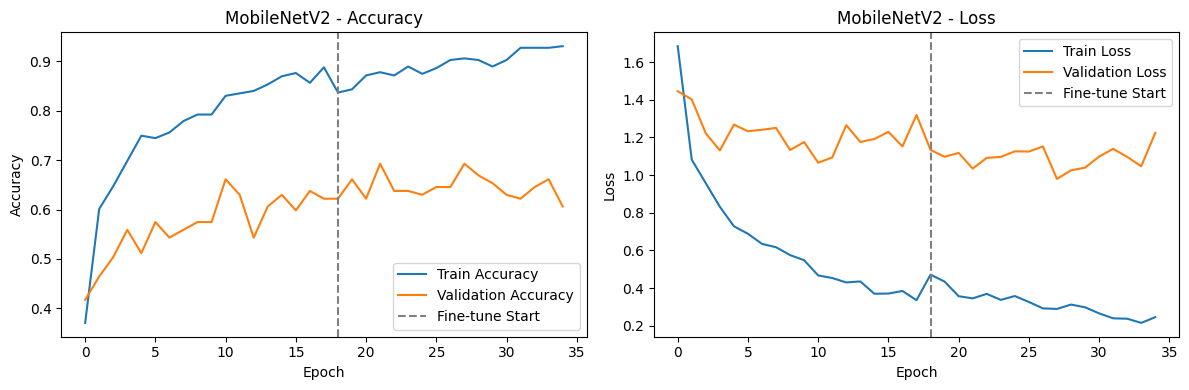

In [23]:
# ------------------------------------------------------------
# Training curves (Phase 1 + Fine-tune combined)
# ------------------------------------------------------------
acc = history.history['accuracy'] + history_finetune.history['accuracy']
val_acc_curve = history.history['val_accuracy'] + history_finetune.history['val_accuracy']

loss = history.history['loss'] + history_finetune.history['loss']
val_loss_curve = history.history['val_loss'] + history_finetune.history['val_loss']

fine_tune_start = len(history.history['accuracy'])

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc_curve, label='Validation Accuracy')
plt.axvline(fine_tune_start, color='gray', linestyle='--', label='Fine-tune Start')
plt.title('MobileNetV2 - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss_curve, label='Validation Loss')
plt.axvline(fine_tune_start, color='gray', linestyle='--', label='Fine-tune Start')
plt.title('MobileNetV2 - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()